In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt

In [5]:
pip install sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install pymysql

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sqlalchemy
engine =sqlalchemy.create_engine('mysql+pymysql://root:@localhost/isjd')

ValueError: invalid literal for int() with base 10: 'http:'

In [1]:
artikel = pd.read_csv("jurnal_aji.csv", names=['id_jurnal', 'id_direktori', 'month', 'number', 'halaman', 'title', 'year'])

NameError: name 'pd' is not defined

In [10]:
artikel

,id_jurnal,id_direktori,month,number,halaman,title,year
0,1090302,102403,November,1,50-56,Peningkatan hasil belajar matematika dengan pe...,2014
1,1046261,13311,Agt.,ed. khusus,127-139,Struktur frasa nomina endosentris bahasa Bugis,2013
2,1013124,519,Juni,2,1306-1314,Kontribusi usahatani padi dan usaha sapi poton...,2013
3,1013125,519,Juni,2,1315-1322,Penyelidikan geokimia panas bumi Lau Sidebuk-d...,2013
4,1013126,519,Juni,2,1323-1334,Penelusuran genetik dan pembentukan kembali ay...,2013
...,...,...,...,...,...,...,...
157341,11227128,110585,July-December,2,133-140,<i>THE EFFECT OF PREGNANCY EXERCISE ON THE SMO...,2018
157342,11227130,110844,Maret,2,36-42,SISTEM AKUNTANSI PEMBELIAN BARANG DAGANG PADA ...,2019
157343,11227131,110585,July-December,2,141-147,<i>RELATIONSHIP BETWEEN PREGNANT WOMEN'S HIGHR...,2018
157344,11227132,110585,July-December,2,148-151,<i>CORRELATION BETWEEN RESPIRATORY FREQUENCY (...,2018


In [57]:
author = pd.read_sql_table("author_baru", engine, columns= ['jurnal_author_id', 'author_id','author_ke', 'id_jurnal'])
author

,jurnal_author_id,author_id,author_ke,id_jurnal
0,688846,173510,1,11201910
1,688845,419029,1,11201909
2,688844,419028,1,11201908
3,688843,173137,1,11201907
4,688842,194230,1,11201906
...,...,...,...,...
482443,739117,295088,1,11227132
482444,739118,442676,2,11227132
482445,739119,442678,4,11227132
482446,739120,169569,3,11227132


In [58]:
master_author =pd.read_sql_table("masterauthor_baru", engine, columns= ['author_id', 'authorname','instansi'])
master_author

,author_id,authorname,instansi
0,76001,Yusni Yetti,None
1,76002,Muslichah,None
2,76003,Sri Indrawati,None
3,76004,Nurhayati,None
4,76005,"Ratnawati, Kusuma",None
...,...,...,...
332676,442677,Nurul Huda,Nursing Academy of Pasuruan Government
332677,442678,Novi Rahmania,Nursing Academy of Pasuruan Government
332678,442679,Leno Wijayanti,"Faculty of Nursing and Midwifery, Nahdlatul Ul..."
332679,442680,Rina Sandora,Shipbuilding Institute of Polytechnic Surabaya


In [43]:
#master_author.info()
author.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482448 entries, 0 to 482447
Data columns (total 4 columns):
jurnal_author_id    482448 non-null int64
author_id           482448 non-null int64
author_ke           482448 non-null object
id_jurnal           482448 non-null int64
dtypes: int64(3), object(1)
memory usage: 14.7+ MB


In [59]:
#author.dropna(axis=0, how='any', thresh=None, subset=None, inplace=True)
#author.author_id.astype(int)


In [61]:
namaAuthor = pd.merge(left=author , right = master_author, left_on='author_id', right_on= 'author_id')
namaAuthor

,jurnal_author_id,author_id,author_ke,id_jurnal,authorname,instansi
0,688846,173510,1,11201910,Eko Susanto,
1,187180,173510,1,1008029,Eko Susanto,
2,187181,173510,1,1014751,Eko Susanto,
3,187182,173510,1,112217,Eko Susanto,
4,187183,173510,2,1017836,Eko Susanto,
...,...,...,...,...,...,...
480151,739115,442673,1,11227131,Siti Fithrotul Umami,Ar-Rahma Midwifery Academy
480152,739114,442675,2,11227129,Latof Syeikhur Rabbani,Shipbuilding Institute of Polytechnic Surabaya
480153,739118,442676,2,11227132,Ayu Dewi Nastiti,Nursing Academy of Pasuruan Government
480154,739119,442678,4,11227132,Novi Rahmania,Nursing Academy of Pasuruan Government


In [62]:
artikelAuthor = pd.merge(left=artikel , right = namaAuthor, left_on='id_jurnal', right_on= 'id_jurnal')
artikelAuthor

,id_jurnal,id_direktori,month,number,halaman,title,year,jurnal_author_id,author_id,author_ke,authorname,instansi
0,1090302,102403.0,November,1,50-56,Peningkatan hasil belajar matematika dengan pe...,2014,575863,86864,1,Warni,None
1,1046261,13311.0,Agt.,ed. khusus,127-139,Struktur frasa nomina endosentris bahasa Bugis,2013,231610,183567,1,Firman A.D.,
2,1013124,519.0,Juni,2,1306-1314,Kontribusi usahatani padi dan usaha sapi poton...,2013,460612,295095,1,Albina Br Ginting,
3,1013125,519.0,Juni,2,1315-1322,Penyelidikan geokimia panas bumi Lau Sidebuk-d...,2013,382908,242804,1,Juliper Nainggolan,
4,1013126,519.0,Juni,2,1323-1334,Penelusuran genetik dan pembentukan kembali ay...,2013,460751,295194,3,Untung Pardosi,
...,...,...,...,...,...,...,...,...,...,...,...,...
274218,11227132,110585.0,July-December,2,148-151,<i>CORRELATION BETWEEN RESPIRATORY FREQUENCY (...,2018,739120,169569,3,Nurul Huda,None
274219,11227132,110585.0,July-December,2,148-151,<i>CORRELATION BETWEEN RESPIRATORY FREQUENCY (...,2018,739117,295088,1,Ida Zuhroidah,
274220,11227132,110585.0,July-December,2,148-151,<i>CORRELATION BETWEEN RESPIRATORY FREQUENCY (...,2018,739118,442676,2,Ayu Dewi Nastiti,Nursing Academy of Pasuruan Government
274221,11227132,110585.0,July-December,2,148-151,<i>CORRELATION BETWEEN RESPIRATORY FREQUENCY (...,2018,739119,442678,4,Novi Rahmania,Nursing Academy of Pasuruan Government


In [55]:
artikelAuthor.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 274288 entries, 0 to 274287
Data columns (total 12 columns):
id_jurnal           274288 non-null int64
id_direktori        269484 non-null object
month               274279 non-null object
number              274244 non-null object
halaman             274244 non-null object
title               274250 non-null object
year                274244 non-null object
jurnal_author_id    274288 non-null int64
author_id           274288 non-null int64
author_ke           274288 non-null object
authorname          274288 non-null object
instansi            257714 non-null object
dtypes: int64(3), object(9)
memory usage: 27.2+ MB


In [63]:
jurnalartikelAuthor = pd.merge(left=artikelAuthor , right = direktori, left_on='id_direktori', right_on= 'id_direktori')
jurnalartikelAuthor

,id_jurnal,id_direktori,month,number,halaman,title,year,jurnal_author_id,author_id,author_ke,authorname,instansi,issn,eissn,judulsebelumnya,judulbaru
0,1090302,102403.0,November,1,50-56,Peningkatan hasil belajar matematika dengan pe...,2014,575863,86864,1,Warni,None,2407-2168,,,
1,1090308,102403.0,November,1,64-70,Metode permainan kartu bilangan meningkatkan h...,2014,537562,357051,1,Titik Purwaningsih,,2407-2168,,,
2,1090311,102403.0,November,1,71-77,Melalui alat peraga meningkatkan hasil belajar...,2014,537563,357052,1,Kalimah,,2407-2168,,,
3,1090313,102403.0,November,1,78-84,Metode bermain peran meningkatkan hasil belaja...,2014,394041,248995,1,Suwartini,,2407-2168,,,
4,1090317,102403.0,November,1,85-91,Metode alat peraga beraneka meningkatkan hasil...,2014,537566,357055,1,M Aselih,,2407-2168,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269222,11227124,110844.0,Maret,2,10-17,ANALISIS PENGARUH KUALITAS PELAYANAN TERHADAP ...,2019,739104,442667,1,Wendy Suhendry,-,2654-7325,2656-7695,,
269223,11227124,110844.0,Maret,2,10-17,ANALISIS PENGARUH KUALITAS PELAYANAN TERHADAP ...,2019,739105,442668,2,Fera Maulina,-,2654-7325,2656-7695,,
269224,11227126,110844.0,Maret,2,18-25,KESESUAIAN PEMBERIAN BESARAN KOMPENSASI DENGAN...,2019,739108,442671,1,Wui San Taslim,-,2654-7325,2656-7695,,
269225,11227127,110844.0,Maret,2,26-35,ANALISIS KUALITAS PELAYANAN FASILITAS KESEHATA...,2019,739109,93240,1,Sugianto,None,2654-7325,2656-7695,,


In [52]:
direktori = pd.read_sql_table("direktori", engine, columns= ['id_direktori', 'issn', 'eissn', 'judulsebelumnya', 'judulbaru'])

In [47]:
category = pd.read_sql_table("category", engine, columns= ['id_direktory', 'issn', ])= [])

SyntaxError: invalid syntax (<ipython-input-47-5a18978c85be>, line 1)

In [18]:
artikelISJD = pd.merge(left=artikel , right = category, left_on='id_category', right_on= 'id_category')
artikelISJD

,id_jurnal,id_direktori,year,deskriptor,id_category,penulis,name_cat
0,1046261,13311,2013,"Noun phrase, Grammar, Syntax, Bugis language",6.0,,Bahasa
1,1038756,101804,2014,"Debates and debatility, Speaking",6.0,,Bahasa
2,1000323,100739,2013,"Indonesian language, Folk literature, Banjar l...",6.0,,Bahasa
3,1000326,100739,2013,"Indonesian language, Sanskrit, Arabic, Vocabul...",6.0,,Bahasa
4,1000369,100739,2013,"Code switching (linguistics), Teaching, Learni...",6.0,,Bahasa
...,...,...,...,...,...,...,...
74121,11193080,12625,2016,"Tourist industry, Ecotourism, Local government...",82.0,,Geografi
74122,11193105,12625,2016,"Travel agents, Tourism, Client satisfaction, P...",82.0,,Geografi
74123,11221915,110173,2018,"Geographic information systems, Mapping",82.0,,Geografi
74124,11221944,110173,2018,"Geographic information systems, Aid coordination",82.0,,Geografi


In [25]:
artikelISJD.drop(['id_category'], axis =1)

,id_jurnal,id_direktori,year,deskriptor,penulis,name_cat
0,1046261,13311,2013,"Noun phrase, Grammar, Syntax, Bugis language",,Bahasa
1,1038756,101804,2014,"Debates and debatility, Speaking",,Bahasa
2,1000323,100739,2013,"Indonesian language, Folk literature, Banjar l...",,Bahasa
3,1000326,100739,2013,"Indonesian language, Sanskrit, Arabic, Vocabul...",,Bahasa
4,1000369,100739,2013,"Code switching (linguistics), Teaching, Learni...",,Bahasa
...,...,...,...,...,...,...
74121,11193080,12625,2016,"Tourist industry, Ecotourism, Local government...",,Geografi
74122,11193105,12625,2016,"Travel agents, Tourism, Client satisfaction, P...",,Geografi
74123,11221915,110173,2018,"Geographic information systems, Mapping",,Geografi
74124,11221944,110173,2018,"Geographic information systems, Aid coordination",,Geografi


In [98]:
artikelISJD.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 74100 entries, 0 to 74125
Data columns (total 7 columns):
id_jurnal       74100 non-null int64
id_direktori    73937 non-null object
year            74100 non-null int32
deskriptor      74086 non-null object
id_category     74100 non-null float64
penulis         74100 non-null object
name_cat        74100 non-null object
dtypes: float64(1), int32(1), int64(1), object(4)
memory usage: 4.2+ MB


In [26]:
extr = artikelISJD['year'].str.extract(r'^(\d{4})', expand=False)

In [64]:
#artikelISJD.to_excel('artikel.xlsx', index = False)
jurnalartikelAuthor.to_csv('artikel with jurnal name and author.csv', index = False)

In [29]:
# delete all rows with column 'Age' has value 30 to 40 
indexYears = artikelISJD[(artikelISJD['year'] <= 2013) & (dfObj['year'] >= 2018)].index
artikelISJD.drop(indexYears , inplace=True)

TypeError: '<=' not supported between instances of 'str' and 'int'

In [99]:
artikelISJD["year"] = artikelISJD["year"].astype(str)

In [69]:
indexYears = artikelISJD[artikelISJD['year'].str.contains("2015http")].index
artikelISJD.drop(indexYears , inplace=True)

In [82]:
indexYears = artikelISJD[(artikelISJD['year'] == '2013/14')].index # & (artikelISJD['year'] == 2014-2015)].index
artikelISJD.drop(indexYears , inplace=True)

In [83]:
hasil = artikelISJD[artikelISJD['year'].str.contains("2013/14")]
hasil
#df[df['A'].str.contains("hello")]

,id_jurnal,id_direktori,year,deskriptor,id_category,penulis,name_cat


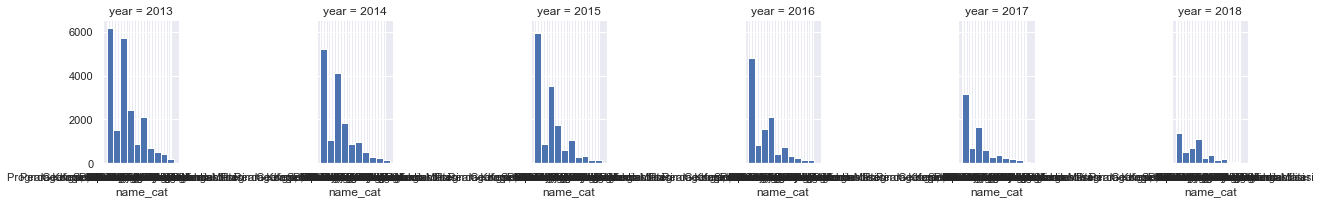

In [105]:
x = sns.FacetGrid(artikelISJD, col ="year")
x.map(plt.hist, 'name_cat')

In [73]:
sns.set(rc={'figure.figsize':(11.7,8.27)})

TypeError: unsupported operand type(s) for /: 'str' and 'int'

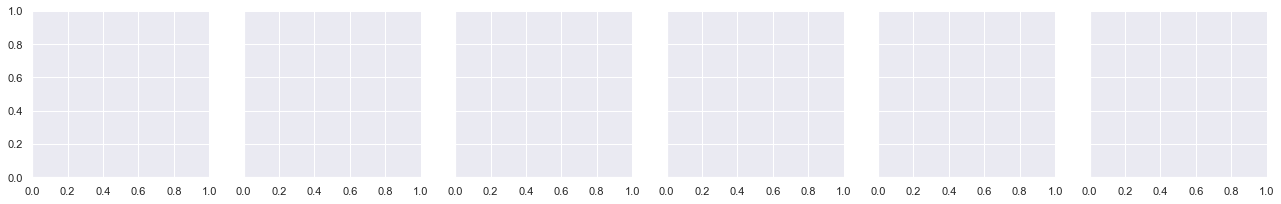

In [100]:
x = sns.FacetGrid(artikelISJD, col ="year")
x.map(sns.barplot(artikelISJD['name_cat'][:10]), color='steelblue')

In [4]:
#define Jaccard Similarity function
def jaccard(list1, list2):
    intersection = len(list(set(list1).intersection(list2)))
    union = (len(list1) + len(list2)) - intersection
    return float(intersection) / union

#find Jaccard Similarity between the two sets 
jaccard(a, b)

0.1111111111111111

In [5]:
import numpy as np

a = [0, 1, 2, 5, 6, 8, 9]
b = [0, 2, 3, 4, 5, 7, 9]

In [12]:
def andre(abc, num):
    for char in abc:
        for int in num:
            print(char, int)
    return

andre(['a','b','c'], [1,2,3])

a 1
a 2
a 3
b 1
b 2
b 3
c 1
c 2
c 3
